In [1]:
import torch
from types import SimpleNamespace # 用于创建简单的配置对象

# 从你的文件中导入必要的类和函数
from moses.char_rnn import CharRNN, CharRNNTrainer

from moses.dataset import get_dataset
from moses.utils import set_torch_seed_to_all_gens

## 分子生成：模型训练

In [3]:
def main():
    # 使用 SimpleNamespace 可以方便地通过点号访问配置项 (e.g., config.lr)
    config = SimpleNamespace(
        # 数据和模型路径
        log_file='logs/char_rnn.log',
        model_save='models/char_rnn.pt',

        # 训练参数
        n_batch=256,
        train_epochs=10,  # 演示文档只设置50轮，真实训练时请提升轮次
        lr=1e-3,
        step_size=5,
        gamma=0.5,
        
        # 模型参数
        hidden=512,
        num_layers=3,
        dropout=0.2,

        # 运行配置
        n_workers=4, # 数据加载器的工作进程数，根据你的CPU核心数调整
        save_frequency=1, # 每隔多少轮保存一次模型
    )

    # 确保日志和模型保存目录存在
    import os
    os.makedirs(os.path.dirname(config.log_file), exist_ok=True)
    os.makedirs(os.path.dirname(config.model_save), exist_ok=True)

    # --- 2. 设置设备 (GPU或CPU) ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # 设置随机种子以保证可复现性
    set_torch_seed_to_all_gens(42)

    # --- 3. 加载数据 ---
    print("Loading data...")
    train_data = get_dataset('train')
    val_data = get_dataset('test') # 使用测试集作为验证集

    # --- 4. 初始化模型和训练器 ---
    print("Initializing model and trainer...")
    trainer = CharRNNTrainer(config)

    # 从训练数据创建词汇表
    vocab = trainer.get_vocabulary(train_data)
    
    # 实例化模型
    model = CharRNN(vocab, config)
    model.to(device)
    
    print("Model initialized:")
    print(model)

    # --- 5. 开始训练 ---
    print("Starting training...")
    trainer.fit(model, train_data, val_data)
    print("Training finished.")

if __name__ == '__main__':
    main()

Using device: cuda
Loading data...
Initializing model and trainer...
Model initialized:
CharRNN(
  (embedding_layer): Embedding(49, 49, padding_idx=47)
  (lstm_layer): LSTM(49, 512, num_layers=3, batch_first=True, dropout=0.2)
  (linear_layer): Linear(in_features=512, out_features=49, bias=True)
)
Starting training...


Training (epoch #0):   0%|          | 0/681 [00:06<?, ?it/s]

Validation (epoch #0):   0%|          | 0/292 [00:06<?, ?it/s]

Training (epoch #1):   0%|          | 0/681 [00:06<?, ?it/s]

Validation (epoch #1):   0%|          | 0/292 [00:06<?, ?it/s]

...

Training (epoch #8):   0%|          | 0/681 [00:06<?, ?it/s]

Validation (epoch #8):   0%|          | 0/292 [00:06<?, ?it/s]

Training (epoch #9):   0%|          | 0/681 [00:06<?, ?it/s]

Validation (epoch #9):   0%|          | 0/292 [00:06<?, ?it/s]

Training finished.


## 分子生成：评估模型生成分子的指标

In [3]:
from moses.utils import CharVocab
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

def main():

    # 我们只需要模型结构相关的参数，不需要训练参数如学习率。
    model_config = SimpleNamespace(
        hidden=512,
        num_layers=3,
        dropout=0.2, # 即使在eval模式下dropout不生效，但模型初始化时需要这个参数
    )
    print("模型配置已定义。")

    # 请将这里的路径修改为你想要加载的实际模型文件。
    model_path = 'models/char_rnn_009.pt'
    print(f"准备加载模型: {model_path}")

    # 最可靠的方法是从原始训练数据中重新生成。
    print("正在从训练数据重新构建词汇表...")
    train_data = get_dataset('train')
    vocab = CharVocab.from_data(train_data)
    print(f"词汇表构建完成，大小为: {len(vocab)}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"将使用设备: {device}")

    # b. 创建一个和保存时结构相同的空模型
    model = CharRNN(vocab, model_config)

    # c. 加载保存的状态字典 (权重和偏置)
    #    map_location=device 确保模型能被正确加载到当前设备上（无论模型当初是在CPU还是GPU上保存的）
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    # d. 将模型实例移动到目标设备
    model.to(device)

    # e. 切换到评估模式 (非常重要!)
    #    这将禁用 Dropout 等只在训练时使用的层。
    model.eval()
    
    print("模型已成功加载并切换到评估模式。")

    print("\n--- 开始生成新的SMILES分子 ---")
    
    with torch.no_grad():
        # 调用模型的 sample 方法生成 100 个新分子
        generated_smiles_list = model.sample(n_batch=1000, max_length=120)
        print("\n--- 生成完毕 ---")
    return generated_smiles_list

if __name__ == '__main__':
    generated_smiles_list = main()
    from moses.metrics import get_all_metrics
    metrics1 = get_all_metrics(generated_smiles_list,n_jobs=4)
    print('metrics:', metrics1)

模型配置已定义。
准备加载模型: models/char_rnn_009.pt
正在从训练数据重新构建词汇表...
词汇表构建完成，大小为: 49
将使用设备: cuda
模型已成功加载并切换到评估模式。

--- 开始生成新的SMILES分子 ---

--- 生成完毕 ---


D:\jupyter\moses\moses\metrics\metrics.py:220: UserWarning: Can't compute unique@1000.gen contains only 865 molecules
  warnings.warn(
D:\jupyter\moses\moses\metrics\metrics.py:220: UserWarning: Can't compute unique@10000.gen contains only 865 molecules
  warnings.warn(


metrics: {'valid': 0.865, 'unique@1000': 0.9930635838150289, 'unique@10000': 0.9930635838150289, 'FCD/Test': np.float64(1.9128069365129363), 'SNN/Test': np.float64(0.6296587104225434), 'Frag/Test': np.float64(0.9917789856807001), 'Scaf/Test': np.float64(0.357143457356599), 'IntDiv': np.float64(0.8746625992714007), 'IntDiv2': np.float64(0.8643878903304507), 'Filters': np.float64(0.8427745664739884), 'logP': np.float64(0.06310023817664964), 'SA': np.float64(0.04865901037992055), 'QED': np.float64(0.016376319314452888), 'weight': np.float64(10.718563155652687), 'Novelty': 0.7869615832363213}


## 分子生成：数据可视化展示

In [33]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import datamol as dm
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole
from rdkit import DataStructs
import rdkit
print(rdkit.__version__)

2024.09.2


In [27]:
train_data = pd.read_csv('./moses/dataset/data/train.csv')['standard_smiles']
test_data = pd.read_csv('./moses/dataset/data/test.csv')['standard_smiles']
gen_mol = pd.DataFrame(generated_smiles_list)[0]

In [28]:
gen_mol

0      Cc1cc(O)cc(C)c1C[C@H](N)C(=O)N1Cc2ccccc2C[C@H]...
1                       CCn1cnc2c(-c3cccc(F)c3)cnc(N)c21
2           CN1[C@H](CCc2ccccc2)CCC[C@@H]1CCc1ccc(OC)cc1
3          C/C=C1/C=CC2CC3C(C)C4C(=O)C(O)C(O)=CC4S=C1C32
4             CSC(=S)N1CC2(CCCCC2)CS/C1=N\c1cccc2ccccc12
                             ...                        
995    O=C1[C@@H]2[C@H]3CC[C@H](C3)[C@@H]2C(=O)N1CCCC...
996    COc1ccccc1N1CCN(CCCCNC(=O)C2CCN(c3ccc4ncccc4c3...
997                     CCN(CC)Cc1ccccc1Sc1ccc(Cl)c(N)c1
998    CCCN1/C(=N\C#N)c2n3c(n(Cc4ccccc4F)c3nc2-c2cccc...
999                               CNC[C@@H](O)CCc1ccccc1
Name: 0, Length: 1000, dtype: object

In [24]:
test_data

0                COc1ccc(C)cc1NC(=O)Nc1ccc(OS(N)(=O)=O)cc1
1                      c1ccc(CC2CCN(CC3Cc4ccccc4C3)CC2)cc1
2        Cc1cccc(-n2nccn2)c1C(=O)N1C[C@H](Oc2cc(C#N)ccn...
3                             Cc1nc(N)nc(N)c1-c1ccc(Cl)cc1
4        CNC(=O)C[C@H]1OC(n2cnc3c(NCc4ccccc4)ncnc32)[C@...
                               ...                        
74638                  NCCc1ccc(S(=O)(=O)n2ccc3ccccc32)cc1
74639             Cn1cc(Nc2ncc(Cl)c(Nc3ccccc3C(N)=O)n2)cn1
74640                 Cc1nccn1CC1CCc2c(c3cccc4c3n2CC4)C1=O
74641    Nc1nccc(-c2ccc(N)c(C(=O)Nc3cnccc3N3CCC[C@H](N)...
74642    COCc1nc(N)c2ncn(C3O[C@H](CO)[C@@H](O)[C@H]3O)c2n1
Name: standard_smiles, Length: 74643, dtype: object

In [29]:
train_data

0         O=C(O)CN[C@@H](C(=O)N1CCC[C@H]1C(=O)NCC#Cc1c[n...
1              Cn1nc(S(N)(=O)=O)s/c1=N/S(=O)(=O)c1ccc(N)cc1
2         COc1ccc(C2CN(C)Cc3cc(OCCCN4CCC(C(F)(F)F)CC4)cc...
3                  COCCN1CCC23CCCC[C@H]2[C@H]1Cc1cc(O)ccc13
4           O=C1CCc2ccc(OCCOCCN3CCN(c4cccc5sccc45)CC3)cc2N1
                                ...                        
174161            Nc1cc(C(F)(F)F)c(S(N)(=O)=O)cc1S(N)(=O)=O
174162    CN(C)c1ccnc2sc(S(=O)(=O)c3ccc(Cl)cc3)c(-c3ccc(...
174163    C[C@@H]1CCCn2ncc(-c3nc(Nc4ccc(N5CCN(C)CC5)cn4)...
174164    COc1cc2c(cc1OC)C(=O)N(CCCCN1CCN(c3ccccn3)CC1)CCC2
174165    Cl.O=C(N[C@@H]1CC[C@@]2(O)[C@H]3Cc4ccc(O)c5c4[...
Name: standard_smiles, Length: 174166, dtype: object

In [32]:
train_mol = [Chem.MolFromSmiles(x) for x in train_data]
test_mol =  [Chem.MolFromSmiles(x) for x in test_data]

In [36]:
gen_m = [dm.to_mol(x) for x in gen_mol if Chem.MolFromSmiles(x) is not None]

[15:51:31] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 18 19 20 22 23 24 26 29
[15:51:31] SMILES Parse Error: extra open parentheses for input: 'Nc1ncnc2c1c(-c1cnc(NC3CCN(CC4(O)CCOC4)CC3)nc1OCCO3'
[15:51:31] SMILES Parse Error: extra open parentheses for input: '[2H]c1c([2H])c([2H])c([C@@H]2C[C@@H](N3CCN(C([2H])([2H])[2H])C(C)(C)C3)c3c(/C=C/C(C)(C)C)cnc3c2n1CCC3'
[15:51:31] Can't kekulize mol.  Unkekulized atoms: 6 7 8
[15:51:31] non-ring atom 27 marked aromatic
[15:51:31] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16 17 30 31 32
[15:51:31] Can't kekulize mol.  Unkekulized atoms: 2 3 4 23 24
[15:51:31] Can't kekulize mol.  Unkekulized atoms: 5 13 15 16 17 18 19 20 22 23 30
[15:51:31] SMILES Parse Error: syntax error while parsing: Fc1ccc(2CCN(c3nnc(C4CCC4)nn3)C2)cc1F
[15:51:31] SMILES Parse Error: Failed parsing SMILES 'Fc1ccc(2CCN(c3nnc(C4CCC4)nn3)C2)cc1F' for input: 'Fc1ccc(2CCN(c3nnc(C4CCC4)nn3)C2)cc1F'
[15:51:31] Can't kekulize mol.  Unkekulized atoms: 2 21
[15:51:31

In [45]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
train_fp = mfpgen.GetFingerprints(train_mol)

In [47]:
test_fp = mfpgen.GetFingerprints(test_mol)
gen_fp = mfpgen.GetFingerprints(gen_m)

In [50]:
tsne = TSNE(n_components=2)
train_pca = tsne.fit_transform(np.array(train_fp))

In [62]:
gen_pca = tsne.fit_transform(np.array(gen_fp))

In [64]:
test_pca = tsne.fit_transform(np.array(test_fp))

In [60]:
train_pca[:,0]

array([ -16.880167, -118.61817 ,   95.4785  , ...,  -63.22668 ,
         84.46964 ,   51.999134], shape=(174166,), dtype=float32)

In [52]:
import seaborn as sns

<Axes: >

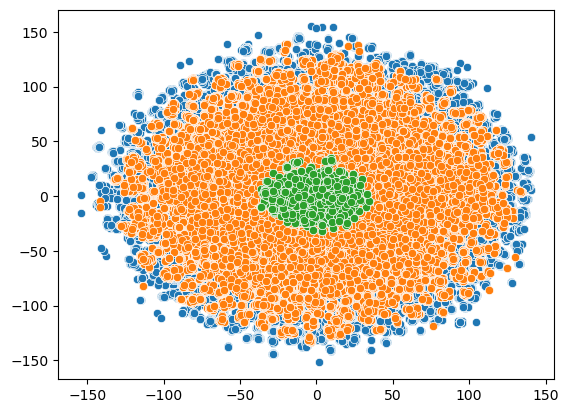

In [67]:
sns.scatterplot(x=train_pca[:,0], y = train_pca[:,1])
sns.scatterplot(x=test_pca[:,0], y = test_pca[:,1])
sns.scatterplot(x=gen_pca[:,0], y = gen_pca[:,1])